<a href="https://colab.research.google.com/github/whps40123-design/LightGBM_model/blob/main/LightGBM%E5%AE%8C%E6%95%B4%E7%89%880228.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#訓練模型階段

##設定環境

In [1]:
# 1. 確保掛載 (如果已掛載，這行執行很快)
from google.colab import drive
drive.mount('/content/drive')

# 2. 定義雲端硬碟路徑 (確保路徑對應到雲端硬碟)
import os
save_path = '/content/drive/MyDrive/XGBoost' # 建議建個資料夾
file_path = os.path.join(save_path, 'all_qualified_models(LGBM).csv')

# 3. 確保資料夾存在 (避免路徑報錯)
if not os.path.exists(save_path):
    os.makedirs(save_path)

Mounted at /content/drive


##載入資料

In [2]:
#載入訓練用資料
import pandas as pd
import numpy as np
data = pd.read_csv('/content/drive/MyDrive/XGBoost/loan_train_36000.csv')
data.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
0,31,1,1,135252,9,0,23000,0,12.18,17.01,6,647,0
1,31,0,2,83842,10,0,22000,4,13.67,26.24,7,654,1
2,31,0,3,103117,7,0,22000,1,11.58,21.33,5,672,0
3,31,0,2,145046,9,0,21600,5,19.03,14.89,5,667,0
4,31,1,1,79766,7,0,21000,0,10.37,26.33,10,540,1


In [3]:
#列出欄位名稱
data.columns

Index(['person_age', 'person_gender', 'person_education', 'person_income',
       'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'loan_status'],
      dtype='object')

##特徵工程

In [4]:
# 定義需要進行 Log 轉換的數值欄位
# 收入與貸款金額通常具有長尾效應（少數人極高），取自然對數降低偏態影響
log_cols = ['person_income', 'loan_amnt']

# 執行 Log 轉換
# 使用 np.log1p 可以確保數值穩定性
for col in log_cols:
    data[col + '_log'] = np.log1p(data[col])

# 查看轉換後的結果
print(data[['person_income', 'person_income_log', 'loan_amnt', 'loan_amnt_log']].head())


   person_income  person_income_log  loan_amnt  loan_amnt_log
0         135252          11.814902      23000      10.043293
1          83842          11.336701      22000       9.998843
2         103117          11.543629      22000       9.998843
3         145046          11.884813      21600       9.980495
4          79766          11.286865      21000       9.952325


In [ ]:
#「信用價值比」 (Credit Value Ratio)
data['credit_value_ratio'] = data['loan_int_rate'] / data['credit_score']
print(data[['credit_value_ratio']].head())



   credit_value_ratio
0            0.018825
1            0.020902
2            0.017232
3            0.028531
4            0.019204


In [ ]:
#「年資負擔比」 (Experience Burden Ratio)
data['experience_burden_ratio'] = data['loan_percent_income'] / (data['person_emp_exp']+1)
print(data[['experience_burden_ratio']].head())

   experience_burden_ratio
0                 1.701000
1                 2.385455
2                 2.666250
3                 1.489000
4                 3.291250


In [ ]:
# 2026/2/20新增
# 財務壓力指數 (Financial Stress Index)
# 邏輯：如果一個人的「收入負債比」很高，同時他的「貸款利率」也很高，這代表他每個月不僅要還很多錢，而且裡面大部分都是利息！這種人的違約機率會呈現指數級上升。
# 強強聯手：將第一名和第四名的特徵相乘
data['financial_stress_index'] = data['loan_percent_income'] * (data['loan_int_rate']/100)

# 剩餘可用絕對所得 (Disposable Income)
# 邏輯：loan_percent_income 是個「比例」。但同樣是貸款佔收入的50%:月入20萬的人，繳完貸款還有10萬可以生活（很安全）。月入4萬的人，繳完貸款只剩2萬（非常危險，一有意外就違約）。
# 假設您原本的 DataFrame 裡有未取 log 的 person_income
data['disposable_income'] = data['person_income'] * (1 - data['loan_percent_income']/100)
# 如果數值很大，建議可以加上 log 處理
data['disposable_income_log'] = np.log1p(data['disposable_income'])

# 首次信用啟用的年齡 (Age at First Credit)
# 邏輯：目前的person_age和cb_person_cred_hist_length(信用歷史長度)單獨看都很弱。但如果你把它們相減：某人40歲，信用歷史才2年(38歲才辦第一張卡/貸款)➡️異常，可能之前信用破產過，或是小白。某人25歲，信用歷史3年(22歲開始累積)➡️正常。
# 搶救弱特徵：抓出異常的信用起步時間
data['age_at_first_credit'] = data['person_age'] - data['cb_person_cred_hist_length']

In [5]:
# 利息壓力，用高借款利率且高負債收入比來捕捉風險
data["interest_pressure"] = data["loan_int_rate"] * data["loan_percent_income"]

##選擇放入模型的特徵

In [12]:
# 放入模型的變數
X = data[['person_age', 'person_gender', 'person_education',
      'person_income_log', 'person_emp_exp',
       'person_home_ownership', 'loan_amnt_log',
       'loan_intent', 'cb_person_cred_hist_length', 'credit_score','loan_int_rate','loan_percent_income']]
#備選特徵： ,'credit_value_ratio','experience_burden_ratio','loan_int_rate','loan_percent_income','interest_pressure'

y = data['loan_status']

##設定參數

In [13]:
import lightgbm as lgb

param_grid = [
    {
        'n_estimators': [1300],        # 配合早停(Early Stopping)通常設大
        'learning_rate': [0.05],       # 較小的學習率能學得更細
        'num_leaves': [15],          # Leaf-wise 的核心，建議小於 2^(max_depth)
        'max_depth': [4],           # 限制深度防止過擬合，-1 為不限制

        # 處理不平衡
        'is_unbalance': [True],        # 自動權重平衡，適合 22% vs 78%
        # 或者可以使用 'model__scale_pos_weight': [3.5], (兩者選其一)

        # 針對過擬合與邊界值的優化：
        'min_child_samples': [300],      # 相當於 min_data_in_leaf，越大模型越保守
        'reg_alpha': [1],           # L1 正則化 (reg_alpha)
        'reg_lambda': [1],          # L2 正則化 (reg_lambda)

        # 隨機採樣，增加模型穩定性
        #'feature_fraction': [0.7, 0.8],      # 每次訓練隨機選取 70%-80% 特徵
        #'bagging_fraction': [0.7, 0.8],      # 每次訓練隨機選取 70%-80% 資料
        #'bagging_freq': [5],            # 每 5 輪進行一次隨機採樣
        'n_jobs': [-1]
    }
]
model = lgb.LGBMClassifier(random_state=42)

In [ ]:
# !pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 5.8 MB/s eta 0:00:00


In [14]:
#將模型放入Pipeline
from sklearn.pipeline import Pipeline
#from category_encoders import TargetEncoder
new_param_grid = []
for pg in param_grid:
    new_param_grid.append({f"model__{k}": v for k, v in pg.items()})

pipe = Pipeline([('model', model)])
pipe

Pipeline(steps=[('model', LGBMClassifier(random_state=42))])

##跑模型

In [20]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, PredefinedSplit, RandomizedSearchCV

# 1. 第一步：切分資料
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. 第二步：建立 PredefinedSplit
# 我們需要告訴 RandomizedSearchCV 哪一部分是訓練，哪一部分是驗證
# -1 代表訓練集, 0 代表驗證集
train_indices = np.full(X_train.shape[0], -1)
val_indices = np.full(X_val.shape[0], 0)
test_fold = np.append(train_indices, val_indices)

ps = PredefinedSplit(test_fold)

# 3. 第三步：合併資料 (因為 RandomizedSearchCV.fit 需要收一個整體的 X 和 y)
X_combined = pd.concat([X_train, X_val])
y_combined = pd.concat([y_train, y_val])

# 4. 第四步：設定 RandomizedSearchCV
scoring = {
    'recall': 'recall',
    'precision_macro': 'precision_macro',
    'f1': 'f1',
    'auc_pr': 'average_precision',
    'roc_auc': 'roc_auc',
    'accuracy': 'accuracy'
}

rcv = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=new_param_grid,
    return_train_score=True,
    scoring=scoring,
    refit='auc_pr',
    n_iter=1,
    cv=ps,        # <--- 這裡改用定義好的 PredefinedSplit，就等於沒有跑 CV
    verbose=2,
    n_jobs=-1
)

# 找出要標註為類別的欄位在 X 中的索引
cat_cols = ['person_gender','person_home_ownership', 'loan_intent']
cat_indices = [X.columns.get_loc(col) for col in cat_cols]

# 看看 cat_indices 是不是一串數字，例如 [0, 2, 5, 6, 8]
print(f"類別欄位的索引位置: {cat_indices}")

# 在 RandomizedSearchCV 的 fit 中傳入參數
# 先定義最乾淨、沒有前綴的原始參數字典
base_fit_params = {
    'categorical_feature': cat_indices,  # 告訴模型哪些是類別欄位
    'eval_set': [(X_train, y_train), (X_val, y_val)], # 告訴模型：看這組資料來決定要不要停止
    'eval_names': ['train', 'valid'],
    'callbacks': [
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100)
    ],
    'eval_metric': ['binary_logloss', 'average_precision']
}

# 透過字典推導式，一口氣幫所有 key 加上 'model__' 前綴
fit_params = {f"model__{k}": v for k, v in base_fit_params.items()}

# 印出來檢查看看，確認前綴都加上去了
print(fit_params)

# 使用合併後的資料進行訓練
rcv.fit(X_combined, y_combined, **fit_params)

# 訓練完成後，你可以直接看結果
print(f"最佳參數: {rcv.best_params_}")
print(f"驗證集最佳 AUC-PR: {rcv.best_score_}")

類別欄位的索引位置: [1, 5, 7]
{'model__categorical_feature': [1, 5, 7], 'model__eval_set': [(       person_age  person_gender  person_education  person_income_log  \
13135          26              0                 1          10.681206   
13028          26              1                 1          10.522154   
19615          25              1                 1          12.132545   
10167          27              0                 2          11.458543   
9142           27              1                 2          10.336989   
...           ...            ...               ...                ...   
5411           29              1                 2          10.718011   
31012          22              1                 0          11.025751   
2224           30              0                 1          11.192913   
30066          23              1                 2          11.166837   
25224          23              0                 0           9.736074   

       person_emp_exp  person_home_owne

##模型評估

[LightGBM] [Info] Number of positive: 6490, number of negative: 22303
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001144 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1307
[LightGBM] [Info] Number of data points in the train set: 28793, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.225402 -> initscore=-1.234459
[LightGBM] [Info] Start training from score -1.234459
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightG

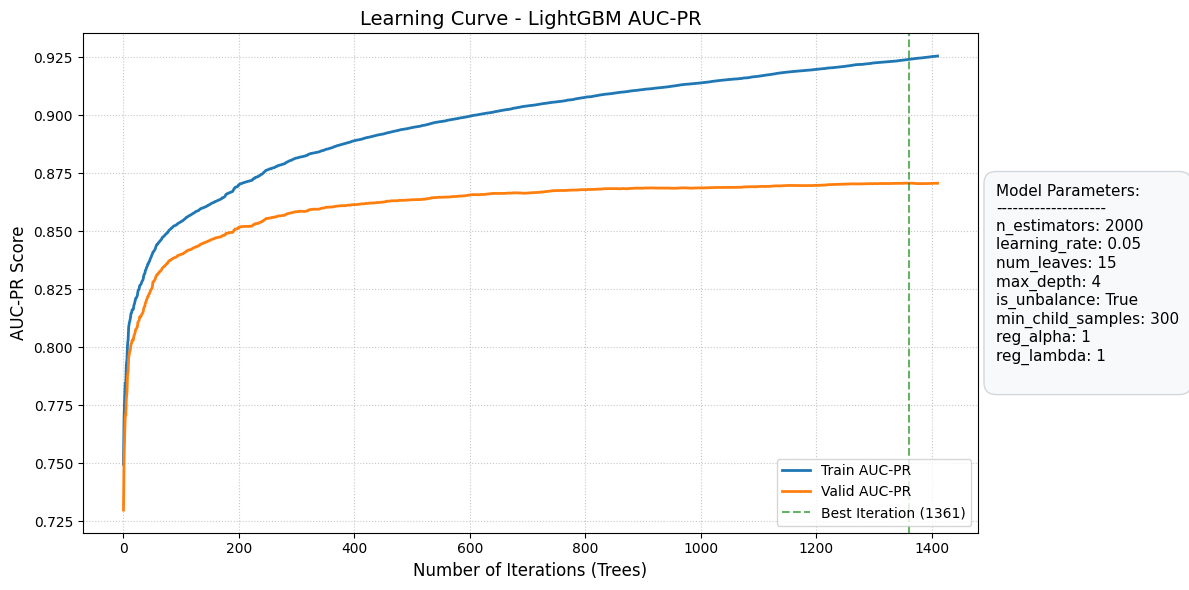


訓練完成！最佳 AUC-PR (驗證集): 0.8707
模型實際在第 1361 棵樹停止。


In [23]:
# ==========================================
# 提取數據並繪製學習曲線(用普通模型才能測出真實的Early Stopping個數，因為RandomizedSearch的refit參數會把所有的資料再跑一次模型，會蓋掉原本的log就看不出真實的學習曲線)
# ==========================================
import matplotlib.pyplot as plt

model = lgb.LGBMClassifier(
    boosting_type = 'gbdt',           # 加在這裡：設定提升算法
    objective = 'binary',             # 加在這裡：設定為二元分類
    n_estimators =2000,              # 配合早停(Early Stopping)通常設大
    learning_rate = 0.05,       # 較小的學習率能學得更細
    num_leaves = 15,              # Leaf-wise 的核心，建議小於 2^(max_depth)
    max_depth = 4,             # 限制深度防止過擬合，-1 為不限制

    # 處理不平衡 (妳特別要求的)
    is_unbalance = True,              # 自動權重平衡，適合 22% vs 78%
    # 或者可以使用 'model__scale_pos_weight': [3.5], (兩者選其一)

    # 針對過擬合與邊界值的優化：
    min_child_samples = 300,  # 相當於 min_data_in_leaf，越大模型越保守
    reg_alpha = 1,            # L1 正則化 (reg_alpha)
    reg_lambda = 1,            # L2 正則化 (reg_lambda)
    # 隨機採樣，增加模型穩定性
    # feature_fraction = 0.7,      # 每次訓練隨機選取 70%-80% 特徵
    # subsample = 0.8,
    # colsample_bytree = 0.8,
    #'bagging_fraction': [0.7, 0.8],      # 每次訓練隨機選取 70%-80% 資料
    n_jobs = -1
)


model.fit(X_train, y_train, **base_fit_params)

# 1. 提取評估結果
evals_result = model.evals_result_
train_auc_pr = evals_result['train']['average_precision']
valid_auc_pr = evals_result['valid']['average_precision']

# 2. 繪製圖表 (把寬度稍微調寬一點，為了放右邊的文字方塊)
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(train_auc_pr, label='Train AUC-PR', color='#1f77b4', linewidth=2)
ax.plot(valid_auc_pr, label='Valid AUC-PR', color='#ff7f0e', linewidth=2)

# 標註 Early Stopping 停止的位置
best_iter = model.best_iteration_
ax.axvline(x=best_iter, color='green', linestyle='--', alpha=0.6, label=f'Best Iteration ({best_iter})')

ax.set_title('Learning Curve - LightGBM AUC-PR', fontsize=14)
ax.set_xlabel('Number of Iterations (Trees)', fontsize=12)
ax.set_ylabel('AUC-PR Score', fontsize=12)
ax.legend(loc='lower right') # 把圖例放在右下角比較不會擋到線
ax.grid(True, linestyle=':', alpha=0.7)

# ==========================================
# 新增：在圖片右側加上參數文字方塊
# ==========================================
# 自動獲取模型參數
params = model.get_params()

# 挑選你想顯示的核心參數 (如果全部印出來會太長)
key_params = [
    'n_estimators', 'learning_rate', 'num_leaves', 'max_depth',
    'is_unbalance', 'min_child_samples', 'reg_alpha', 'reg_lambda'
]

# 將參數組裝成多行字串
param_text = "Model Parameters:\n" + "-"*20 + "\n"
for k in key_params:
    param_text += f"{k}: {params.get(k)}\n"

# 在圖上加上文字方塊
# transform=ax.transAxes 讓座標以圖表比例 (0~1) 計算，x=1.02 代表在圖表右邊緣再往外一點
ax.text(1.02, 0.5, param_text, transform=ax.transAxes,
        fontsize=11, verticalalignment='center',
        bbox=dict(boxstyle='round,pad=0.8', facecolor='#f8f9fa', edgecolor='#ced4da', alpha=0.9))

# ==========================================

# 調整排版，確保右側的文字方塊不會被切掉
plt.tight_layout()
import datetime

# 1. 取得現在的時間，並格式化成 YYYYMMDD_HHMMSS 的字串 (例如：20260220_143000)
current_time = datetime.datetime.now().strftime("%m%d_%H%M%S")

# 2. 將時間加進檔名中
file_path = f'/content/drive/MyDrive/XGBoost/learning_curve_{current_time}.png'

# 3. 存檔 (加上 bbox_inches='tight' 可以避免右側文字方塊被切掉)
plt.savefig(file_path, dpi=300, bbox_inches='tight')
print(f"圖表已存檔至：{file_path}")
plt.show()

# 輸出結果
best_score = model.best_score_['valid']['average_precision']
print(f"\n訓練完成！最佳 AUC-PR (驗證集): {best_score:.4f}")
print(f"模型實際在第 {best_iter} 棵樹停止。")

In [16]:
print("平均分數 (train vs test)：")
for score_name in scoring:
    train_key = f'mean_train_{score_name}'
    test_key = f'mean_test_{score_name}'
    train_score = rcv.cv_results_[train_key].mean()
    test_score = rcv.cv_results_[test_key].mean()
    print(f"{score_name}: Train={train_score:.4f}, Test={test_score:.4f}")

平均分數 (train vs test)：
recall: Train=0.8613, Test=0.7837
precision_macro: Train=0.8686, Test=0.8316
f1: Train=0.8180, Test=0.7547
auc_pr: Train=0.9225, Test=0.8705
roc_auc: Train=0.9673, Test=0.9305
accuracy: Train=0.9136, Test=0.8851


In [ ]:
#詳細數據
rcv.cv_results_

{'mean_fit_time': array([7.96645737]),
 'std_fit_time': array([0.]),
 'mean_score_time': array([0.9137857]),
 'std_score_time': array([0.]),
 'param_model__num_leaves': masked_array(data=[31],
              mask=[False],
        fill_value=999999),
 'param_model__n_estimators': masked_array(data=[3000],
              mask=[False],
        fill_value=999999),
 'param_model__min_child_samples': masked_array(data=[200],
              mask=[False],
        fill_value=999999),
 'param_model__max_depth': masked_array(data=[5],
              mask=[False],
        fill_value=999999),
 'param_model__learning_rate': masked_array(data=[0.05],
              mask=[False],
        fill_value=1e+20),
 'param_model__lambda_l2': masked_array(data=[1],
              mask=[False],
        fill_value=999999),
 'param_model__lambda_l1': masked_array(data=[1],
              mask=[False],
        fill_value=999999),
 'param_model__is_unbalance': masked_array(data=[True],
              mask=[False],
        f

In [ ]:
# 1. 先確認 RandomizedSearchCV 已經執行完 fit 了
# 2. 從 rcv 中提取「最佳管道 (Best Estimator)」
best_pipeline = rcv.best_estimator_

# 3. 從管道中提取名為 'model' 的步驟 (假設您的 Pipeline 步驟名稱是 'model')
# 如果沒用 Pipeline，就直接 best_lgb = rcv.best_estimator_
best_lgb = best_pipeline.named_steps['model']

# 4. 現在可以安全地查看 best_iteration_
print(f"最佳疊代次數 (Best Iteration): {best_lgb.best_iteration_}")

最佳疊代次數 (Best Iteration): 3000


In [ ]:
# 模型內建判斷的最佳參數，但要注意過擬合問題
rcv.best_params_

{'model__scale_pos_weight': 3.5,
 'model__reg_lambda': 1,
 'model__reg_alpha': 0.5,
 'model__n_estimators': 400,
 'model__min_child_weight': 7,
 'model__max_depth': 4,
 'model__learning_rate': 0.05}

In [ ]:
# 查看某一組參數
best_num = 0
print("params:",rcv.cv_results_['params' ] [best_num])
print("mean_train_auc_pr:",rcv.cv_results_['mean_train_auc_pr'] [best_num])
print("mean_test_auc_pr:",rcv.cv_results_['mean_test_auc_pr'] [best_num])
print("mean_train_roc_auc:",rcv.cv_results_['mean_train_roc_auc'] [best_num])
print("mean_test_roc_auc:",rcv.cv_results_['mean_test_roc_auc'] [best_num])
print("mean_train_f1:",rcv.cv_results_['mean_train_f1'] [best_num])
print("mean_test_f1:",rcv.cv_results_['mean_test_f1'] [best_num])



params: {'model__num_leaves': 15, 'model__n_jobs': -1, 'model__n_estimators': 1300, 'model__min_child_samples': 300, 'model__max_depth': 4, 'model__learning_rate': 0.05, 'model__lambda_l2': 1, 'model__lambda_l1': 1, 'model__is_unbalance': True}
mean_train_auc_pr: 0.9181411309868471
mean_test_auc_pr: 0.8663605416898584
mean_train_roc_auc: 0.9656622783270639
mean_test_roc_auc: 0.9282077444836642
mean_train_f1: 0.8114193216098889
mean_test_f1: 0.7493277561995817


In [ ]:
rcv.best_index_

np.int64(4)

##紀錄參數數據

In [ ]:
import pandas as pd
import os
from datetime import datetime

# --- 1. 定義固定參數欄位 ---
master_param_cols = ['model__n_estimators', 'model__learning_rate', 'model__max_depth',
                     'model__num_leaves', 'model__min_child_samples', 'model__lambda_l1', 'model__lambda_l2']

results_df = pd.DataFrame(rcv.cv_results_)
# 第一道篩選：基礎分數門檻
mask = (results_df['mean_train_auc_pr'] > 0.86) & (results_df['mean_test_auc_pr'] > 0.86)
good_models = results_df[mask].copy()

if not good_models.empty:
    # A. 展開參數並補齊 Master 欄位
    params_expanded = pd.json_normalize(good_models['params'])
    params_expanded = params_expanded.reindex(columns=master_param_cols + list(set(params_expanded.columns) - set(master_param_cols)))

    # B. 選擇分數欄位
    metrics_cols = metrics_cols = [
        'mean_train_auc_pr', 'mean_test_auc_pr',
        'mean_train_roc_auc', 'mean_test_roc_auc',
        'mean_train_f1', 'mean_test_f1',
        'mean_train_precision_macro', 'mean_test_precision_macro',
        'mean_train_recall', 'mean_test_recall',
        'mean_train_accuracy', 'mean_test_accuracy',
    ]

    # C. 建立本次初步 DataFrame
    new_data = pd.concat([params_expanded.reset_index(drop=True),
                          good_models[metrics_cols].reset_index(drop=True)], axis=1)

    # D. 計算過擬合差距 (Gap)
    new_data['auc_pr_gap'] = new_data['mean_train_auc_pr'] - new_data['mean_test_auc_pr']

    # ✨【新增重點】：第二道篩選 - 嚴格過濾掉 Gap > 0.05 的組合
    # 只有符合 auc_pr_gap <= 0.05 的才會留下來
    new_data = new_data[new_data['auc_pr_gap'] <= 0.045].copy()

    if not new_data.empty:
        new_data['timestamp'] = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

        # --- 2. 存檔邏輯 ---
        file_path = '/content/drive/MyDrive/XGBoost/all_qualified_models(LGBM).csv'

        if os.path.isfile(file_path):
            old_data = pd.read_csv(file_path)
            combined_df = pd.concat([old_data, new_data], ignore_index=True, sort=False)
        else:
            combined_df = new_data

        # 排序：優先看測試集表現
        # combined_df = combined_df.sort_values(by='mean_test_auc_pr', ascending=False)
        # combined_df.to_csv(file_path, index=False)
        # 按時間排序，讓最新的實驗結果在最上面
        combined_df = combined_df.sort_values(by='timestamp', ascending=False)
        combined_df.to_csv(file_path, index=False)

        print(f"✅ 品管通過！本次共有 {len(new_data)} 組組合符合 Gap <= 0.05 並已存檔。")
    else:
        print("⚠️ 雖然分數達標，但所有組合的 Gap 都大於 0.05（過擬合嚴重），本次不予存檔。")
else:
    print("❌ 分數未達標，不予存檔。")

In [ ]:
import pandas as pd

# 確保你已經執行過 drive.mount('/content/drive')
file_path1 = '/content/drive/MyDrive/XGBoost/all_qualified_models(LGBM).csv'

try:
    history = pd.read_csv(file_path1)
    print("✅ 成功讀取雲端硬碟紀錄！")
    display(history)
except FileNotFoundError:
    print("❌ 找不到檔案！請檢查：")
    print("1. 左側資料夾是否有出現 'drive' 資料夾？(沒掛載)")
    print("2. 檔案是否真的存在於 MyDrive 根目錄下？")

✅ 成功讀取雲端硬碟紀錄！


,model__n_estimators,model__learning_rate,model__max_depth,model__num_leaves,model__min_child_samples,model__lambda_l1,model__lambda_l2,model__is_unbalance,mean_train_auc_pr,mean_test_auc_pr,...,mean_train_f1,mean_test_f1,mean_train_precision_macro,mean_test_precision_macro,mean_train_recall,mean_test_recall,mean_train_accuracy,mean_test_accuracy,auc_pr_gap,timestamp
0,2000,0.05,3,31,200,10,10,True,0.911482,0.866599,...,0.802919,0.744118,0.858395,0.822923,0.847766,0.779421,0.906192,0.879150,0.044883,2026-02-18 15:42:38
1,2000,0.05,3,15,500,10,1,True,0.903098,0.864070,...,0.789020,0.749928,0.847932,0.823311,0.839291,0.797289,0.898830,0.880122,0.039028,2026-02-18 15:42:38
2,2000,0.05,3,31,500,10,1,True,0.903098,0.864070,...,0.789020,0.749928,0.847932,0.823311,0.839291,0.797289,0.898830,0.880122,0.039028,2026-02-18 15:42:38
3,2000,0.05,3,31,500,10,10,True,0.902217,0.865203,...,0.789432,0.749781,0.849288,0.824864,0.835593,0.791128,0.899524,0.880956,0.037014,2026-02-18 15:42:38
4,2000,0.05,3,31,500,1,1,True,0.907369,0.865807,...,0.795560,0.751168,0.852437,0.825809,0.844838,0.792360,0.902129,0.881650,0.041562,2026-02-18 15:42:38
5,2000,0.05,3,15,500,10,10,True,0.902217,0.865203,...,0.789432,0.749781,0.849288,0.824864,0.835593,0.791128,0.899524,0.880956,0.037014,2026-02-18 15:42:38


##儲存模型

In [ ]:
# 方法一

import pickle

with open("model.bin", "wb") as f:
    pickle.dump(rcv.best_estimator_, f)

In [ ]:
# 方法二
import pickle
import zipfile
import os
from datetime import datetime
from google.colab import drive

# 1. 掛載 Google Drive (如果還沒掛載的話)
drive.mount('/content/drive')

# 2. 設定儲存路徑與檔名
file_path = '/content/drive/MyDrive/XGBoost'
model_name = "LightGBM_Model"
version = "v1"
timestamp = datetime.now().strftime("%Y%m%d_%H%M")

# 確保資料夾存在，如果不存在就建立它
if not os.path.exists(file_path):
    os.makedirs(file_path)
    print(f"📁 已建立新資料夾: {file_path}")

# 組合完整的儲存路徑 (檔名包含路徑)
zip_filename = f"model_{model_name}_{version}_{timestamp}.zip"
full_zip_path = os.path.join(file_path, zip_filename)
internal_filename = "model.bin"

# 3. 執行壓縮儲存
try:
    with zipfile.ZipFile(full_zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
        # 將模型序列化
        model_bytes = pickle.dumps(rcv.best_estimator_)
        # 寫入 ZIP
        zf.writestr(internal_filename, model_bytes)

    print(f"✨ 儲存成功！")
    print(f"📍 儲存位置: {full_zip_path}")
except Exception as e:
    print(f"❌ 儲存失敗，錯誤原因: {e}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✨ 儲存成功！
📍 儲存位置: /content/drive/MyDrive/XGBoost/model_LightGBM_Model_v1_20260221_0638.zip


In [ ]:

zip_filename

'model_LightGBM_v1_20260221_0621.zip'

##feature_importance

In [ ]:
from sklearn.inspection import permutation_importance

result = permutation_importance(rcv, X, y, scoring='average_precision', n_repeats=5, random_state=42)

importances = result.importances_mean
features = X.columns

# 組成 (feature, importance) 清單
feature_importance = list(zip(features, importances))

# 依 importance 由大到小排序
feature_importance_sorted = sorted(feature_importance, key=lambda x: x[1], reverse=True)

for feature, importance in feature_importance_sorted:
    print(f"{feature}: {importance:.4f}")


loan_percent_income: 0.3538
person_home_ownership: 0.1937
person_income_log: 0.1835
loan_int_rate: 0.1487
loan_intent: 0.0737
loan_amnt_log: 0.0157
credit_value_ratio: 0.0081
credit_score: 0.0077
person_age: 0.0063
cb_person_cred_hist_length: 0.0037
person_emp_exp: 0.0034
person_education: 0.0009
person_gender: 0.0005


##劃出混淆矩陣

In [ ]:
import plotly.express as px
import pandas as pd
from sklearn.metrics import confusion_matrix

# 預測
y_pred = rcv.predict(X)

# 計算混淆矩陣
cm = confusion_matrix(y, y_pred)
labels = rcv.classes_  # pipeline 最後分類器的類別

# 轉成 DataFrame
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

# 用 Plotly 畫熱力圖
fig = px.imshow(
    cm_df,
    text_auto=True,       # 顯示數字
    color_continuous_scale="Blues",
    labels=dict(x="Predicted Label", y="True Label", color="Count"),
)

fig.update_layout(
    title="Confusion Matrix (Train Data)",
    xaxis_title="Predicted Label",
    yaxis_title="True Label"
)

fig.show()


#測試階段

##匯入測試集

In [ ]:
import pandas as pd
import numpy as np
data = pd.read_csv('/content/drive/MyDrive/XGBoost/loan_test_9000.csv')   # <- 這邊要改成實際的檔案
data.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
0,28,1,2,72824,4,1,4000,0,7.90,5.49,8,615,0
1,22,1,0,91172,4,0,6000,3,11.01,6.58,2,528,1
2,23,0,1,79539,5,0,20000,4,13.22,25.14,2,584,1
3,28,1,2,37011,6,0,7700,1,12.42,20.80,8,682,0
4,24,0,2,76408,2,1,6300,2,11.49,8.25,4,618,0


##特徵工程

In [ ]:
# 定義需要進行 Log 轉換的數值欄位
log_cols = ['person_income', 'loan_amnt']

# 執行 Log 轉換
# 使用 np.log1p 可以確保數值穩定性
for col in log_cols:
    data[col + '_log'] = np.log1p(data[col])

# 查看轉換後的結果
print(data[['person_income', 'person_income_log', 'loan_amnt', 'loan_amnt_log']].head())

   person_income  person_income_log  loan_amnt  loan_amnt_log
0          72824          11.195815       4000       8.294300
1          91172          11.420514       6000       8.699681
2          79539          11.284015      20000       9.903538
3          37011          10.518997       7700       8.949105
4          76408          11.243856       6300       8.748464


In [ ]:
#列出欄位名稱
data.columns

Index(['person_age', 'person_gender', 'person_education', 'person_income',
       'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'loan_status', 'person_income_log', 'loan_amnt_log'],
      dtype='object')

In [ ]:
X = data[['person_age', 'person_gender', 'person_education',
      'person_income_log', 'person_emp_exp',
       'person_home_ownership', 'loan_amnt_log',
       'loan_intent', 'loan_int_rate',
       'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']]


y = data['loan_status']

In [ ]:
# print(data.columns.tolist())

In [ ]:
# 載入模型
import pickle
f =  open("model.bin", "rb")  # <- 這邊要改成實際的檔案
model =  pickle.load(f)
model

Pipeline(steps=[('model',
                 LGBMClassifier(is_unbalance=True, learning_rate=0.05,
                                max_depth=4, min_child_samples=300,
                                n_estimators=1300, n_jobs=-1, num_leaves=15,
                                random_state=42, reg_alpha=1, reg_lambda=1))])

##匯入已儲存的模型

In [ ]:
# #ZIP版
import pickle
import zipfile
import os

# 修改為你雲端硬碟中的實際完整路徑
file_path = '/content/drive/MyDrive/XGBoost'
zip_filename = 'model_LightGBM_v1_20260221_0621.zip'
target_full_path = os.path.join(file_path, f"{zip_filename}")


if os.path.exists(target_full_path):
    with zipfile.ZipFile(target_full_path, "r") as zf:
        with zf.open("model.bin") as f:
            loaded_model = pickle.load(f)
    print("✅ 已從雲端硬碟成功載入模型！")
else:
    print("❌ 找不到檔案，請確認路徑是否正確。")

✅ 已從雲端硬碟成功載入模型！


##測試集分數及混淆矩陣

In [ ]:
import plotly.express as px
import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score, roc_auc_score,average_precision_score
)

# 取得分類預測
y_pred = model.predict(X)



print("測試組 Accuracy:", accuracy_score(y, y_pred))
print("測試組 Balanced Accuracy:", balanced_accuracy_score(y, y_pred))
print("測試組 F1:", f1_score(y, y_pred, average='macro'))
print("測試組 Precision:", precision_score(y, y_pred, average='macro'))
print("測試組 Recall:", recall_score(y, y_pred, average='macro'))

# roc_auc_score 必須用機率值
try:
    # 加上 [:, 1] 取出正類別 (類別 1) 的預測機率，變成 1D 陣列
    y_prob = model.predict_proba(X)[:, 1]

    # 二元分類直接計算即可，不需要 multi_class 與 average 參數
    print("測試組 ROC AUC:", roc_auc_score(y, y_prob))

except AttributeError:
    print("模型沒有 predict_proba，無法計算 ROC AUC")

auc_pr = average_precision_score(y, y_prob)
print(f"測試組 AUC-PR Score: {auc_pr:.4f}")


# 計算混淆矩陣
cm = confusion_matrix(y, y_pred)
labels = model.classes_  # pipeline 最後分類器的類別

# 轉成 DataFrame
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

# 用 Plotly 畫熱力圖
fig = px.imshow(
    cm_df,
    text_auto=True,       # 顯示數字
    color_continuous_scale="Blues",
    labels=dict(x="Predicted Label", y="True Label", color="Count"),
)

fig.update_layout(
    title="Confusion Matrix",
    xaxis_title="Predicted Label",
    yaxis_title="True Label"
)

fig.show()

測試組 Accuracy: 0.9116666666666666
測試組 Balanced Accuracy: 0.8905357142857143
測試組 F1: 0.876654890986972
測試組 Precision: 0.8649141775915665
測試組 Recall: 0.8905357142857143
測試組 ROC AUC: 0.960864642857143
測試組 AUC-PR Score: 0.9130


In [ ]:
# print("\n=== 最佳參數組合 ===")
# print(rcv.best_params_)

# print(f"\n最佳 Cross-Validation AUC-PR: {rcv.best_score_:.4f}")

# # 取得最佳模型
# best_model = rcv.best_estimator_

# (選用) 如果您有額外的測試集 X_test, y_test Final Test Report (9,000 Samples)
from sklearn.metrics import classification_report, confusion_matrix

print("\n=============================================")
print("\nFinal Test Report (9,000 Samples)")
print("\n=============================================")
print("\n=== Test Set Metrics ===")
print("Accuracy:", accuracy_score(y, y_pred))
print("F1:", f1_score(y, y_pred, average='macro'))
print("ROC-AUC:", roc_auc_score(y_true, y_prob_positive))

y_pred = model.predict(X)
print("\n=== classification_report ===")
print(classification_report(y, y_pred))



Final Test Report (9,000 Samples)


=== Test Set Metrics ===
Accuracy: 0.9116666666666666
F1: 0.876654890986972
ROC-AUC: 0.960864642857143

=== classification_report ===
              precision    recall  f1-score   support

           0       0.96      0.93      0.94      7000
           1       0.77      0.85      0.81      2000

    accuracy                           0.91      9000
   macro avg       0.86      0.89      0.88      9000
weighted avg       0.92      0.91      0.91      9000

